# 1.1.1 Deep Learning on MNIST

**Hardware Used:**
* Processor: Intel(R) Core(TM) i5-4570
* Frequency: 3.20GHz
* Cores: 4 cores
* Accelerator: None

**Executive Summary:**
The objective of this exercise is to reach a target test accuracy of 0.97 on the MNIST dataset as fast as possible. 
* **Baseline:** Using a standard CNN architecture, the model reaches 0.97 test accuracy in around `23 seconds` (training time).
* **Optimization 1**: Large Mini-Batch & Linear Scaling
* **Optimization 2**: Parameter Reduction
* **Optimization 3**: Sub-Epoch Early Stopping

In [51]:
import time
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from keras.layers import Conv2D, Dense, Dropout, Flatten, MaxPooling2D
from keras.models import Sequential
from keras.callbacks import Callback
from keras.layers import Input

class TimeAndAccuracyStopper(Callback):
    """
    Custom callback to stop training when a target validation accuracy is reached,
    and to measure the exact time taken to reach it.
    """
    def __init__(self, target_accuracy=0.97):
        super().__init__()
        self.target_accuracy = target_accuracy
        self.start_time = None
        self.end_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        # We explicitly monitor 'val_accuracy' (test dataset score)
        val_acc = logs.get('val_accuracy')

        if val_acc is not None and val_acc >= self.target_accuracy:
            self.end_time = time.time()
            elapsed_time = self.end_time - self.start_time
            print(f"\n--- Target validation accuracy of {self.target_accuracy} reached! ---")
            print(f"Stopping training at epoch {epoch + 1}.")
            print(f"Total training time: {elapsed_time:.2f} seconds (s)")
            self.model.stop_training = True

In [52]:
# Load the data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess the dataset
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype("float32")
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype("float32")

# Normalize the vectors codes (Initially, their maximum value is 255)
x_train = x_train / 255.0
x_test = x_test / 255.0

print(f"Train samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")

Train samples: 60000
Test samples: 10000


In [61]:
# Build the baseline Convolutional Network
model = Sequential([
    Input(shape=(28, 28, 1)), # <-- Added explicit Input layer here
    Conv2D(28, kernel_size=(3, 3), activation=tf.nn.relu), # <-- Removed input_shape from here
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation=tf.nn.relu),
    Dropout(0.2),
    Dense(10, activation=tf.nn.softmax)
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Initialize our custom tracker
stopper = TimeAndAccuracyStopper(target_accuracy=0.97)

# Fit the model WITH validation data and our custom callback
start_time = time.time()
history = model.fit(
    x=x_train,
    y=y_train,
    validation_data=(x_test, y_test),
    batch_size=32,
    epochs=10,
    callbacks=[stopper],
    verbose=1
)
time_baseline = time.time() - start_time
print(f"Baseline Time Saved: {time_baseline:.2f}s")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8973 - loss: 0.3457
--- Target validation accuracy of 0.97 reached! ---
Stopping training at epoch 1.
Total training time: 23.88 seconds (s)
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9486 - loss: 0.1742 - val_accuracy: 0.9798 - val_loss: 0.0634
Baseline Time Saved: 24.06s


### Method 1: Large Mini-Batch & Linear Scaling
* **Theory:** Larger batches allow the CPU to vectorize operations, processing faster. To maintain learning quality, we apply the Linear Scaling Rule (*Goyal et al., 2017*): scaling the learning rate proportionally to the batch size.
* **Action:** Increased batch size from 32 to 512. Scaled Adam LR proportionally.

In [62]:
from keras.optimizers import Adam

# 1. Calculate the Linear Scaling Rule
old_batch_size = 32
new_batch_size = 512
k_factor = new_batch_size / old_batch_size

# Default Adam LR is 0.001
scaled_learning_rate = 0.001 * k_factor
print(f"Scaling Batch Size by {k_factor}x.")
print(f"New Learning Rate: {scaled_learning_rate}")

# 2. Build the exact same model architecture for a fair comparison
model_scaled = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(28, kernel_size=(3, 3), activation=tf.nn.relu),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation=tf.nn.relu),
    Dropout(0.2),
    Dense(10, activation=tf.nn.softmax)
])

# 3. Compile with the scaled custom learning rate
custom_optimizer = Adam(learning_rate=scaled_learning_rate)

model_scaled.compile(
    optimizer=custom_optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# 4. Initialize a fresh timer
stopper_scaled = TimeAndAccuracyStopper(target_accuracy=0.97)

# 5. Train with the new batch size
print("\n--- Starting Large Mini-Batch Training ---")
start_time = time.time()
history_scaled = model_scaled.fit(
    x=x_train,
    y=y_train,
    validation_data=(x_test, y_test),
    batch_size=new_batch_size, # <-- The new large batch size
    epochs=10,
    callbacks=[stopper_scaled],
    verbose=1
)
time_scaled = time.time() - start_time

Scaling Batch Size by 16.0x.
New Learning Rate: 0.016

--- Starting Large Mini-Batch Training ---
Epoch 1/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8410 - loss: 0.4803
--- Target validation accuracy of 0.97 reached! ---
Stopping training at epoch 1.
Total training time: 11.06 seconds (s)
118/118 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.9348 - loss: 0.2054 - val_accuracy: 0.9804 - val_loss: 0.0550


### Method 2: Parameter Reduction
* **Theory:** A physically smaller neural network requires fewer mathematical operations per image, which should theoretically speed up each epoch.
* **Action:** Reduced Conv2D filters (28 → 16) and Dense neurons (128 → 32).

In [58]:
# 1. Build a "Lighter" Convolutional Network
model_light = Sequential([
    Input(shape=(28, 28, 1)),
    # Reduced filters from 28 to 16
    Conv2D(16, kernel_size=(3, 3), activation=tf.nn.relu),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    # Reduced dense neurons from 128 to 32
    Dense(32, activation=tf.nn.relu),
    Dropout(0.2),
    Dense(10, activation=tf.nn.softmax)
])

model_light.compile(
    optimizer="adam", # Back to standard Adam
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# 2. Initialize a fresh timer
stopper_light = TimeAndAccuracyStopper(target_accuracy=0.97)

# 3. Train the lighter model (using baseline batch_size of 32)
print("\n--- Starting Parameter Reduction Training ---")
start_time = time.time()
history_light = model_light.fit(
    x=x_train,
    y=y_train,
    validation_data=(x_test, y_test),
    batch_size=32,
    epochs=10,
    callbacks=[stopper_light],
    verbose=1
)
time_light = time.time() - start_time


--- Starting Parameter Reduction Training ---
Epoch 1/10
1870/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8197 - loss: 0.5746
--- Target validation accuracy of 0.97 reached! ---
Stopping training at epoch 1.
Total training time: 13.02 seconds (s)
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8984 - loss: 0.3350 - val_accuracy: 0.9706 - val_loss: 0.0954


### Method 3: Sub-Epoch Early Stopping
* **Theory:** Standard Keras only evaluates at the end of an epoch. If we evaluate mid-epoch, we can stop the moment we hit 0.97 and save time. 
* **Action:** Custom callback to evaluate test accuracy every 50 batches.

In [59]:
class SubEpochStopper(Callback):
    """
    Evaluates the model every N batches. Stops training mid-epoch
    if the target accuracy is reached.
    """
    def __init__(self, x_test, y_test, target_accuracy=0.97, check_every_n=50):
        super().__init__()
        self.x_test = x_test
        self.y_test = y_test
        self.target_accuracy = target_accuracy
        self.check_every_n = check_every_n
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()

    def on_train_batch_end(self, batch, logs=None):
        # Check validation accuracy every 'check_every_n' batches
        if batch > 0 and batch % self.check_every_n == 0:
            # Evaluate silently (verbose=0) so we don't spam the console
            loss, val_acc = self.model.evaluate(self.x_test, self.y_test, verbose=0)

            if val_acc >= self.target_accuracy:
                elapsed_time = time.time() - self.start_time
                print(f"\n--- Target validation accuracy of {self.target_accuracy} reached at batch {batch}! ---")
                print(f"Total training time: {elapsed_time:.2f} seconds (s)")
                self.model.stop_training = True

# 1. Build the baseline Convolutional Network again
model_sub = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(28, kernel_size=(3, 3), activation=tf.nn.relu),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation=tf.nn.relu),
    Dropout(0.2),
    Dense(10, activation=tf.nn.softmax)
])

model_sub.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# 2. Initialize our Sub-Epoch stopper (checking every 50 batches)
stopper_sub = SubEpochStopper(x_test, y_test, target_accuracy=0.97, check_every_n=50)

# 3. Fit the model
print("\n--- Starting Sub-Epoch Evaluation Training ---")
start_time = time.time()
history_sub = model_sub.fit(
    x=x_train,
    y=y_train,
    batch_size=32,
    epochs=10,
    callbacks=[stopper_sub],
    verbose=1
)
time_sub = time.time() - start_time


--- Starting Sub-Epoch Evaluation Training ---
Epoch 1/10
 946/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - accuracy: 0.9188 - loss: 0.2681
--- Target validation accuracy of 0.97 reached at batch 950! ---
Total training time: 32.89 seconds (s)
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9709 - loss: 0.0957


### Visual Comparison

To summarize the optimization process, the following chart compares the wall-clock time required for each method to reach the target 0.97 validation accuracy. 

As demonstrated visually, **Optimization 1 (Large Mini-Batch)** significantly outperforms both the baseline and the other optimization attempts.

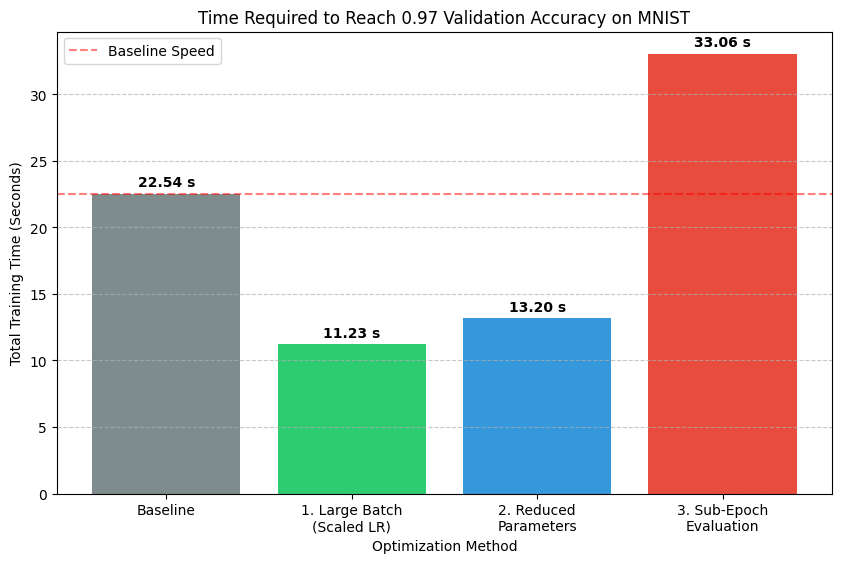

In [60]:
import matplotlib.pyplot as plt

# Using the dynamic variables captured from the previous cells
methods = [
    'Baseline',
    '1. Large Batch\n(Scaled LR)',
    '2. Reduced\nParameters',
    '3. Sub-Epoch\nEvaluation'
]
times_seconds = [time_baseline, time_scaled, time_light, time_sub]

# Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(methods, times_seconds, color=['#7f8c8d', '#2ecc71', '#3498db', '#e74c3c'])

# Add the exact time as text above each bar for readability
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f"{yval:.2f} s",
             ha='center', va='bottom', fontweight='bold')

# Draw a dashed red line across the dynamic baseline
plt.axhline(y=time_baseline, color='r', linestyle='--', alpha=0.5, label='Baseline Speed')

# Mandatory Guidelines: Labels and Units
plt.title('Time Required to Reach 0.97 Validation Accuracy on MNIST')
plt.xlabel('Optimization Method')
plt.ylabel('Total Training Time (Seconds)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()